<a href="https://colab.research.google.com/github/hassan310120/MSc-Final-Project/blob/main/Kepler.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Install Libraries

In [2]:
!pip install astropy lightkurve astroquery oktopus xgboost tqdm -q

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 63.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 64.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.3.0

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. Import Relevant Libraries

In [4]:
import lightkurve as lk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import os
import time
import astropy
from astropy.timeseries import BoxLeastSquares
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
import sklearn
from sklearn.svm import SVC
import xgboost as xgb
from xgboost import XGBClassifier
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc, ConfusionMatrixDisplay
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import interp1d
import warnings
warnings.filterwarnings('ignore')

print("lightkurve  :", lk.__version__)
print("numpy       :", np.__version__)
print("astropy     :", astropy.__version__)
print("pandas      :", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost     :", xgb.__version__)
print()
print("All libraries loaded")

lightkurve  : 2.6.0
numpy       : 2.0.2
astropy     : 7.2.0
pandas      : 2.2.2
scikit-learn: 1.6.1
xgboost     : 3.2.0

All libraries loaded


3. Working on Kepler data for this single star (8367947)

In [ ]:
search_result = lk.search_lightcurve('KIC 8367947', mission='Kepler')
print(search_result)

SearchResult containing 18 data products.

 #       mission      year author exptime  target_name  distance
                                     s                   arcsec 
--- ----------------- ---- ------ ------- ------------- --------
  0 Kepler Quarter 00 2009 Kepler    1800 kplr008367947      0.0
  1 Kepler Quarter 01 2009 Kepler    1800 kplr008367947      0.0
  2 Kepler Quarter 02 2009 Kepler    1800 kplr008367947      0.0
  3 Kepler Quarter 03 2009 Kepler    1800 kplr008367947      0.0
  4 Kepler Quarter 04 2010 Kepler    1800 kplr008367947      0.0
  5 Kepler Quarter 05 2010 Kepler    1800 kplr008367947      0.0
  6 Kepler Quarter 06 2010 Kepler    1800 kplr008367947      0.0
  7 Kepler Quarter 07 2010 Kepler    1800 kplr008367947      0.0
  8 Kepler Quarter 10 2011 Kepler    1800 kplr008367947      0.0
  9 Kepler Quarter 08 2011 Kepler    1800 kplr008367947      0.0
 10 Kepler Quarter 09 2011 Kepler    1800 kplr008367947      0.0
 11 Kepler Quarter 11 2012 Kepler    1800 kplr0

Total data points: 65504
Time span: 1470.5 days
Quarters stitched: 18


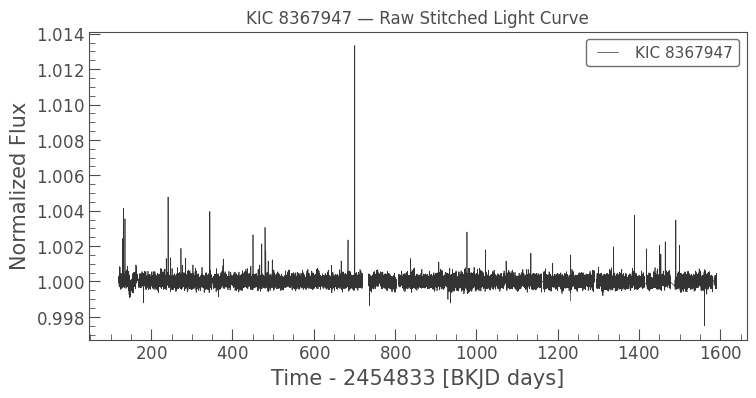

In [ ]:
# Download all quarters
lc_collection = search_result.download_all()

# Stitch into a single continuous light curve
lc = lc_collection.stitch()

# Basic info
print(f"Total data points: {len(lc.time)}")
print(f"Time span: {lc.time.value[-1] - lc.time.value[0]:.1f} days")
print(f"Quarters stitched: {len(lc_collection)}")

# Plot of raw stitched light curve
lc.plot()
plt.title('KIC 8367947 — Raw Stitched Light Curve')
plt.show()

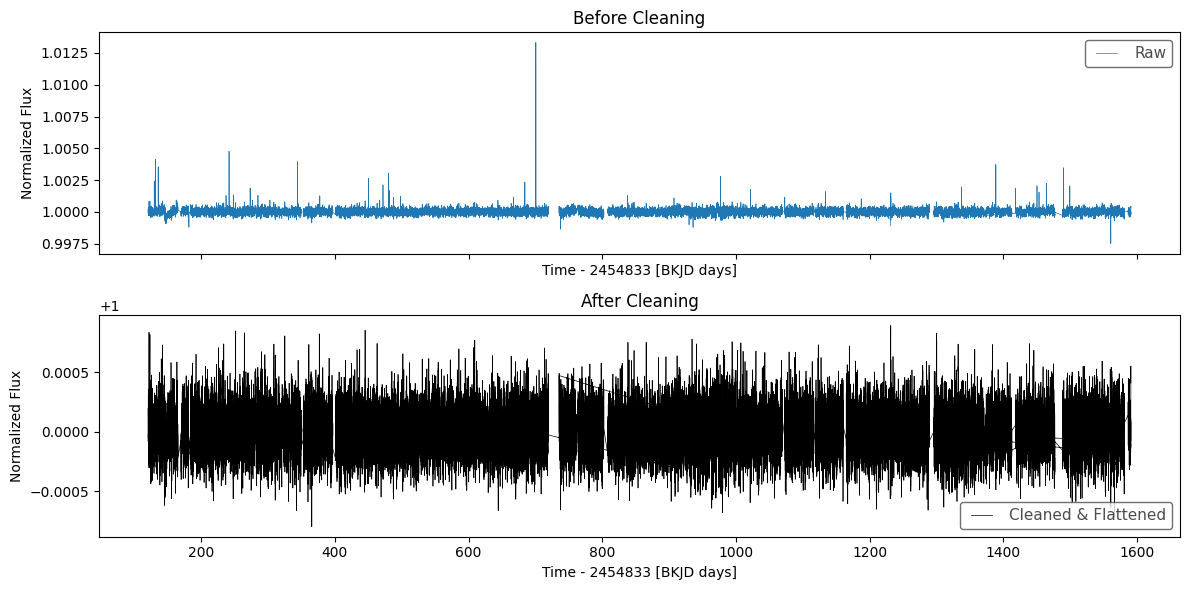

Points before cleaning: 65504
Points after cleaning:  65214
Points removed:         290


In [ ]:
# Preprocessing
# Remove NaN values
lc_clean = lc.remove_nans()

# Remove outliers
lc_clean = lc_clean.remove_outliers(sigma=5)

# Flatten
lc_flat = lc_clean.flatten(window_length=401)

# Compare before and after
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

lc.plot(ax=axes[0], label='Raw')
axes[0].set_title('Before Cleaning')

lc_flat.plot(ax=axes[1], label='Cleaned & Flattened', color='black')
axes[1].set_title('After Cleaning')

plt.tight_layout()
plt.show()

print(f"Points before cleaning: {len(lc.time)}")
print(f"Points after cleaning:  {len(lc_flat.time)}")
print(f"Points removed:         {len(lc.time) - len(lc_flat.time)}")

In [ ]:
# specific star search in the KOI table
koi_info = NasaExoplanetArchive.query_criteria(
    table='q1_q17_dr25_koi',
    where="kepid=8367947"
)

if len(koi_info) > 0:
    print(f"KOIs found for KIC 8367947: {len(koi_info)}")
    print()
    for row in koi_info:
        print(f"  KOI:          {row['kepoi_name']}")
        print(f"  Disposition:  {row['koi_disposition']}")
        print(f"  Period:       {row['koi_period']:.4f} days")
        print(f"  Transit depth:{row['koi_depth']:.1f} ppm")
        print(f"  Planet radius:{row['koi_prad']:.2f} Earth radii")
        print()
else:
    print("This star has no KOIs — it is not a planet candidate host.")

This star has no KOIs — it is not a planet candidate host.


In [ ]:
# Trying a confirmed planet host: Kepler-10 (KIC 11904151)

koi_info = NasaExoplanetArchive.query_criteria(
    table='q1_q17_dr25_koi',
    where="kepid=11904151"
)

for row in koi_info:
    print(f"  KOI:           {row['kepoi_name']}")
    print(f"  Disposition:   {row['koi_disposition']}")
    print(f"  Period:        {row['koi_period']:.4f} days")
    print(f"  Transit depth: {row['koi_depth']:.1f} ppm")
    print(f"  Planet radius: {row['koi_prad']:.2f} Earth radii")
    print()

  KOI:           K00072.01
  Disposition:   CONFIRMED
  Period:        0.8375 d days
  Transit depth: 190.4 ppm ppm
  Planet radius: 1.43 earthRad Earth radii

  KOI:           K00072.02
  Disposition:   CONFIRMED
  Period:        45.2942 d days
  Transit depth: 477.1 ppm ppm
  Planet radius: 2.26 earthRad Earth radii



4. Processing Confirmed Star

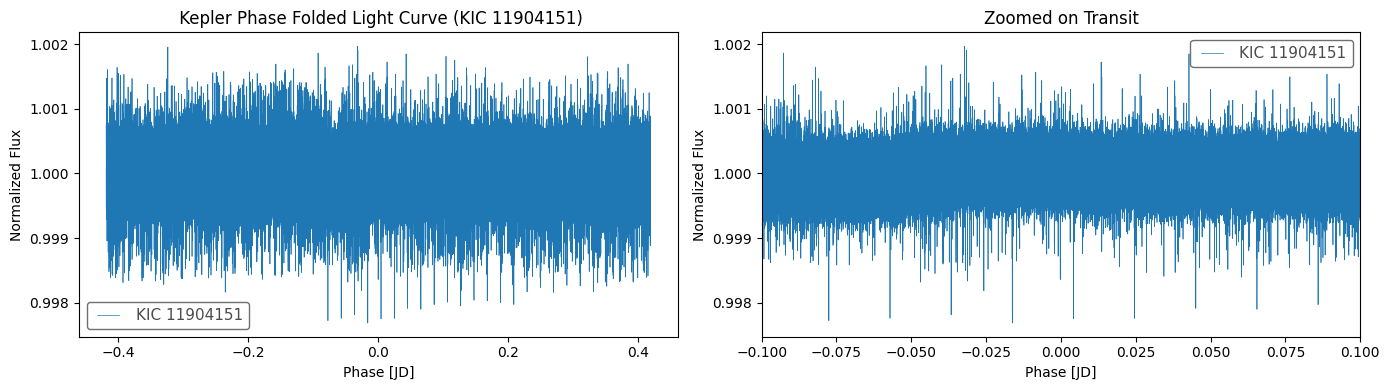

In [ ]:
# Download Kepler Star
search = lk.search_lightcurve('KIC 11904151', mission='Kepler')
lc_collection = search.download_all()
lc = lc_collection.stitch().remove_nans().remove_outliers(sigma=5)
lc = lc.flatten(window_length=401)

# Phase fold on shorter period planet
period = 0.8375
lc_folded = lc.fold(period=period)

# Plot of phase-folded light curve
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left Plot - folded view
lc_folded.plot(ax=axes[0])
axes[0].set_title(f' Kepler Phase Folded Light Curve (KIC 11904151)')

# Right Plot - Zoomed in ±10% on the transit
lc_folded.plot(ax=axes[1])
axes[1].set_xlim(-0.1, 0.1)
axes[1].set_title('Zoomed on Transit')

plt.tight_layout()
plt.show()

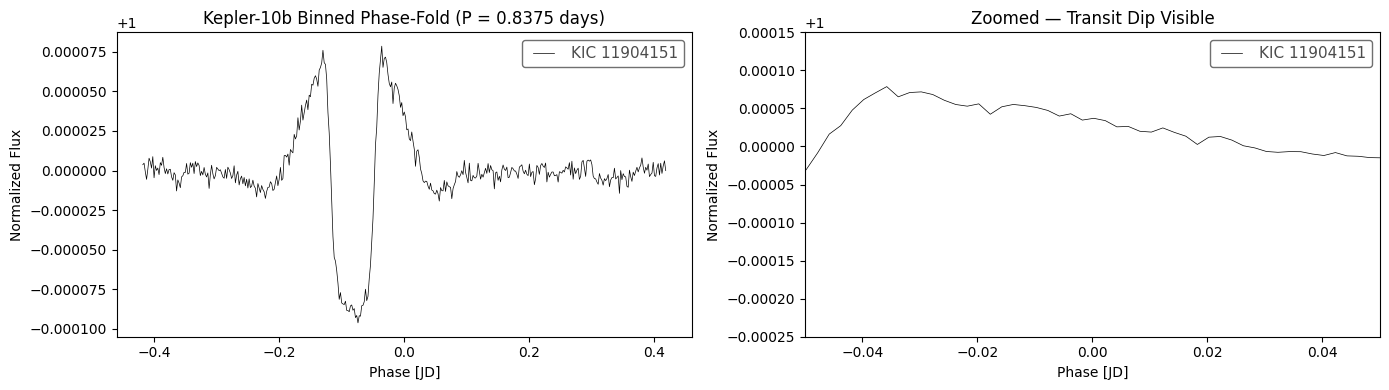

In [ ]:
# Bin the phase-folded light curve to reveal the transit
lc_binned = lc_folded.bin(time_bin_size=0.002)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left plot - phase view, binned
lc_binned.plot(ax=axes[0], color='black', markersize=2)
axes[0].set_title(f'Kepler-10b Binned Phase-Fold (P = {period} days)')

# Right plot - zoomed on the transit
lc_binned.plot(ax=axes[1], color='black', markersize=3)
axes[1].set_xlim(-0.05, 0.05)
axes[1].set_ylim(0.99975, 1.00015)
axes[1].set_title('Zoomed — Transit Dip Visible')

plt.tight_layout()
plt.show()

Transit epoch: 131.574858 BKJD


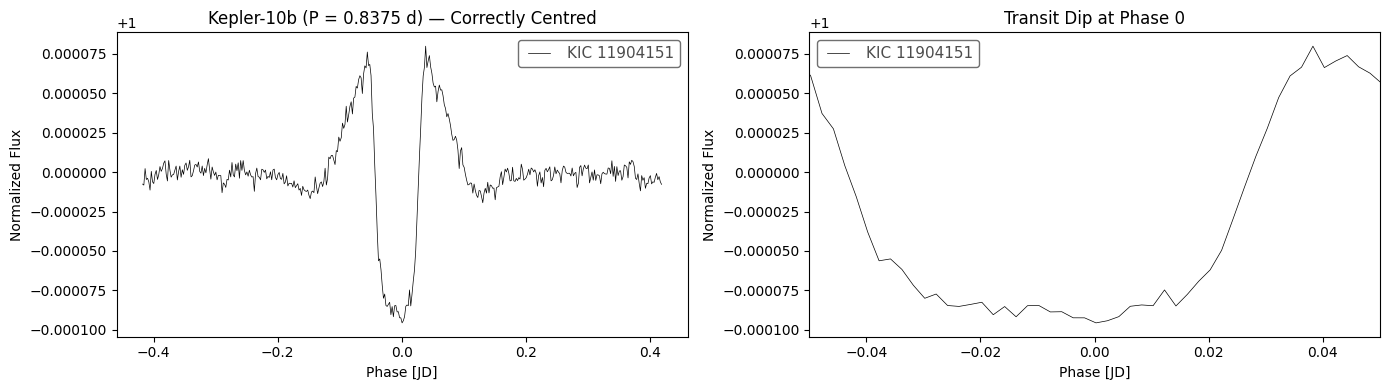

In [ ]:
# epoch - time of first transit
epoch = float(koi_info[0]['koi_time0bk'])
print(f"Transit epoch: {epoch} BKJD")

# Folding with the correct epoch so the transit centres
lc_folded = lc.fold(period=period, epoch_time=epoch)
lc_binned = lc_folded.bin(time_bin_size=0.002)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left plot - full phase view
lc_binned.plot(ax=axes[0], color='black', markersize=2)
axes[0].set_title(f'Kepler-10b (P = {period} d) — Correctly Centred')

# Righ plot - zoomed on transit
lc_binned.plot(ax=axes[1], color='black', markersize=3)
axes[1].set_xlim(-0.05, 0.05)
axes[1].set_title('Transit Dip at Phase 0')

plt.tight_layout()
plt.show()

5. Making Folder in Google Drive

In [ ]:
project_dir = '/content/drive/MyDrive/kepler_project_final'
for folder in ['data', 'figures', 'outputs']:
    os.makedirs(f'{project_dir}/{folder}', exist_ok=True)

print(f"Project directory: {project_dir}")
print("Folders created:")
for folder in os.listdir(project_dir):
    print(f"  📁 {folder}")

Project directory: /content/drive/MyDrive/kepler_project_final
Folders created:
  📁 data
  📁 figures
  📁 outputs


6. Download the KOI Table

In [ ]:
# full DR25 KOI table with key columns
koi_table = NasaExoplanetArchive.query_criteria(
    table='q1_q17_dr25_koi',
    select='kepid,kepoi_name,koi_disposition,koi_period,koi_time0bk,'
           'koi_depth,koi_duration,koi_prad,koi_teq,koi_insol,'
           'koi_steff,koi_slogg,koi_srad'
)

# Convert to pandas DataFrame
df_koi = koi_table.to_pandas()

# Quick summary
print(f"Total KOIs: {len(df_koi)}")
print(f"\nDisposition breakdown:")
print(df_koi['koi_disposition'].value_counts())
print(f"\nColumns: {list(df_koi.columns)}")

# Saved to Google Drive
save_path = '/content/drive/MyDrive/kepler_project_final/data/koi_table_dr25.csv'
df_koi.to_csv(save_path, index=False)
print(f"\nSaved to: {save_path}")

Total KOIs: 8054

Disposition breakdown:
koi_disposition
FALSE POSITIVE    3965
CONFIRMED         2729
CANDIDATE         1360
Name: count, dtype: int64

Columns: ['kepid', 'kepoi_name', 'koi_disposition', 'koi_period', 'koi_time0bk', 'koi_depth', 'koi_duration', 'koi_prad', 'koi_teq', 'koi_insol', 'koi_steff', 'koi_slogg', 'koi_srad']

Saved to: /content/drive/MyDrive/kepler_project_final/data/koi_table_dr25.csv


7. Sample Selection

In [ ]:
df_koi = pd.read_csv('/content/drive/MyDrive/kepler_project_final/data/koi_table_dr25.csv')

# Filter to only confirmed and false positive
df_labelled = df_koi[df_koi['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()

# Creating binary label: 1 = confirmed planet, 0 = false positive
df_labelled['label'] = (df_labelled['koi_disposition'] == 'CONFIRMED').astype(int)

# Dropping rows with missing period or depth
df_labelled = df_labelled.dropna(subset=['koi_period', 'koi_depth'])

print(f"Labelled KOIs with complete data: {len(df_labelled)}")
print(f"\nLabel distribution:")
print(f"  Confirmed planets (1): {df_labelled['label'].sum()}")
print(f"  False positives   (0): {(df_labelled['label'] == 0).sum()}")
print(f"\nPeriod range: {df_labelled['koi_period'].min():.2f} — {df_labelled['koi_period'].max():.2f} days")
print(f"Depth range:  {df_labelled['koi_depth'].min():.1f} — {df_labelled['koi_depth'].max():.1f} ppm")

# Save to Drive
save_path = '/content/drive/MyDrive/kepler_project_final/data/koi_labelled.csv'

Labelled KOIs with complete data: 6639

Label distribution:
  Confirmed planets (1): 2728
  False positives   (0): 3911

Period range: 0.30 — 1071.23 days
Depth range:  0.8 — 921671.0 ppm


In [ ]:
# stratified sample of 300 KOIs
df_sample, _ = train_test_split(
    df_labelled,
    train_size=300,
    stratify=df_labelled['label'],
    random_state=42
)

print(f"Sample size: {len(df_sample)}")
print(f"\nLabel distribution in sample:")
print(f"  Confirmed planets (1): {df_sample['label'].sum()}")
print(f"  False positives   (0): {(df_sample['label'] == 0).sum()}")
print(f"\nPeriod range: {df_sample['koi_period'].min():.2f} — {df_sample['koi_period'].max():.2f} days")

# Get unique star IDs (some stars host multiple KOIs)
unique_stars = df_sample['kepid'].nunique()
print(f"\nUnique stars to download: {unique_stars}")

# Save to Drive
save_path = '/content/drive/MyDrive/kepler_project_final/data/koi_sample_300.csv'
df_sample.to_csv(save_path, index=False)

Sample size: 300

Label distribution in sample:
  Confirmed planets (1): 123
  False positives   (0): 177

Period range: 0.48 — 1064.27 days

Unique stars to download: 294


In [ ]:
# Load sample star list
df_sample = pd.read_csv('/content/drive/MyDrive/kepler_project_final/data/koi_sample_300.csv')
unique_stars = df_sample['kepid'].dropna().astype(int).unique()

# Output paths
features_path = '/content/drive/MyDrive/kepler_project_final/data/features_progress.csv'
failed_path = '/content/drive/MyDrive/kepler_project_final/data/failed_stars.csv'

# Resume previous progress
if os.path.exists(features_path):
    df_done = pd.read_csv(features_path)
    done_ids = set(df_done['kepid'].astype(int).values)
    print(f"Resuming — {len(done_ids)} stars already processed")
else:
    df_done = pd.DataFrame()
    done_ids = set()
    print("Starting fresh")

remaining = [kid for kid in unique_stars if kid not in done_ids]
print(f"Stars remaining: {len(remaining)}")

# Reset failed file header if not exists
if not os.path.exists(failed_path):
    with open(failed_path, 'w') as f:
        f.write("kepid,error\n")

# Feature extraction
def extract_features(lc, kepid):
    flux = np.asarray(lc.flux.value, dtype=float)
    time_vals = np.asarray(lc.time.value, dtype=float)

    features = {
        'kepid': int(kepid),
        'n_datapoints': len(flux),
        'time_span': float(time_vals[-1] - time_vals[0]),
        'mean_flux': float(np.mean(flux)),
        'std_flux': float(np.std(flux)),
        'median_flux': float(np.median(flux)),
        'flux_skew': float(pd.Series(flux).skew()),
        'flux_kurtosis': float(pd.Series(flux).kurtosis()),
        'flux_range': float(np.max(flux) - np.min(flux)),
        'percentile_5': float(np.percentile(flux, 5)),
        'percentile_95': float(np.percentile(flux, 95)),
        'mad_flux': float(np.median(np.abs(flux - np.median(flux)))),
    }
    return features

# Light curve cleaning (with fallback for masked array bug)
def clean_and_prepare_lightcurve(kid):
    search = lk.search_lightcurve(f'KIC {kid}', mission='Kepler', exptime=1800)

    if len(search) == 0:
        raise ValueError("No light curve found")

    lc_collection = search.download_all()

    if lc_collection is None or len(lc_collection) == 0:
        raise ValueError("Download returned no data")

    # Manual per-quarter extraction and normalisation
    time_arrays = []
    flux_arrays = []

    for lc_single in lc_collection:
        t = np.ascontiguousarray(lc_single.time.value, dtype=np.float64)
        f = np.ascontiguousarray(lc_single.flux.value, dtype=np.float64)

        # Remove NaN/Inf
        mask = np.isfinite(t) & np.isfinite(f)
        t, f = t[mask], f[mask]

        if len(f) > 0:
            # Normalise each quarter by its median
            flux_arrays.append(f / np.nanmedian(f))
            time_arrays.append(t)

    if len(time_arrays) == 0:
        raise ValueError("No valid data across any quarter")

    # Combine all quarters
    time_vals = np.concatenate(time_arrays)
    flux_vals = np.concatenate(flux_arrays)

    # Sort by time
    sort_idx = np.argsort(time_vals)
    time_vals = time_vals[sort_idx]
    flux_vals = flux_vals[sort_idx]

    if len(time_vals) < 500:
        raise ValueError("Too few valid points after cleaning")

    # Build clean LightCurve object
    lc = lk.LightCurve(time=time_vals, flux=flux_vals)

    # Remove outliers
    lc = lc.remove_outliers(sigma=5)

    if len(lc) < 500:
        raise ValueError("Too few points after outlier removal")

    # Flatten
    n_points = len(lc)
    window_length = min(401, n_points - 1 if n_points % 2 == 0 else n_points)
    if window_length % 2 == 0:
        window_length -= 1
    if window_length < 11:
        raise ValueError("Too few points for flattening")

    lc = lc.flatten(window_length=window_length)

    return lc

# Main processing loop
batch_results = []

for i, kid in enumerate(tqdm(remaining, desc="Processing stars")):
    try:
        lc = clean_and_prepare_lightcurve(kid)

        features = extract_features(lc, kid)
        batch_results.append(features)

        # Save every 5 successful stars
        if len(batch_results) >= 5:
            df_batch = pd.DataFrame(batch_results)
            df_done = pd.concat([df_done, df_batch], ignore_index=True)
            df_done.to_csv(features_path, index=False)
            batch_results = []
            print(f"\n  Saved progress: {len(df_done)} stars total")

    except Exception as e:
        with open(failed_path, 'a') as f:
            f.write(f"{kid},{str(e)}\n")

# Final save
if batch_results:
    df_batch = pd.DataFrame(batch_results)
    df_done = pd.concat([df_done, df_batch], ignore_index=True)
    df_done.to_csv(features_path, index=False)

print(f"\nDone! Total stars processed: {len(df_done)}")
print(f"Saved to: {features_path}")
print(f"Failures logged to: {failed_path}")

Starting fresh
Stars remaining: 294


Processing stars:   2%|▏         | 5/294 [00:52<50:23, 10.46s/it]


  Saved progress: 5 stars total


Processing stars:   3%|▎         | 10/294 [01:39<47:58, 10.14s/it]


  Saved progress: 10 stars total


...


  Saved progress: 285 stars total


Processing stars:  99%|█████████▉| 291/294 [57:39<01:15, 25.23s/it]


  Saved progress: 290 stars total


Processing stars: 100%|██████████| 294/294 [58:38<00:00, 11.97s/it]


Done! Total stars processed: 293
Saved to: /content/drive/MyDrive/kepler_project_final/data/features_progress.csv
Failures logged to: /content/drive/MyDrive/kepler_project_final/data/failed_stars.csv


8. Loading Features and KOI Sample

In [7]:
# Load features and KOI sample
features = pd.read_csv('/content/drive/MyDrive/kepler_project_final/data/features_progress.csv')
koi_sample = pd.read_csv('/content/drive/MyDrive/kepler_project_final/data/koi_sample_300.csv')

print(f"Features: {len(features)} stars")
print(f"KOI sample: {len(koi_sample)} entries")

# Merge on kepid
df = koi_sample.merge(features, on='kepid', how='inner')

# Save merged dataset
df.to_csv('/content/drive/MyDrive/kepler_project_final/data/merged_dataset.csv', index=False)

print(f"Merged dataset: {len(df)} rows")
print(f"\nLabel distribution:")
print(df['label'].value_counts())
# Overview of all features
print(df.describe().round(4).to_string())



Features: 293 stars
KOI sample: 300 entries
Merged dataset: 299 rows

Label distribution:
label
0    176
1    123
Name: count, dtype: int64
              kepid  koi_period  koi_time0bk    koi_depth  koi_duration  koi_prad    koi_teq    koi_insol  koi_steff  koi_slogg  koi_srad     label  n_datapoints  time_span  mean_flux  std_flux  median_flux  flux_skew  flux_kurtosis  flux_range  percentile_5  percentile_95  mad_flux
count  2.990000e+02    299.0000     299.0000     299.0000      299.0000  299.0000   299.0000     299.0000   299.0000   299.0000  299.0000  299.0000      299.0000   299.0000   299.0000  299.0000     299.0000   299.0000       299.0000    299.0000      299.0000       299.0000  299.0000
mean   7.548388e+06     32.2539     155.1792   40001.0472        5.3151   24.0931  1139.6522    5063.7492  5727.4482     4.3230    2.1086    0.4114    57671.1003  1383.1513     0.9988    0.0046       1.0000    -0.4440         6.6669      0.0372        0.9883         1.0030    0.0013
std    2

9. Exploring Features Distribution by Label

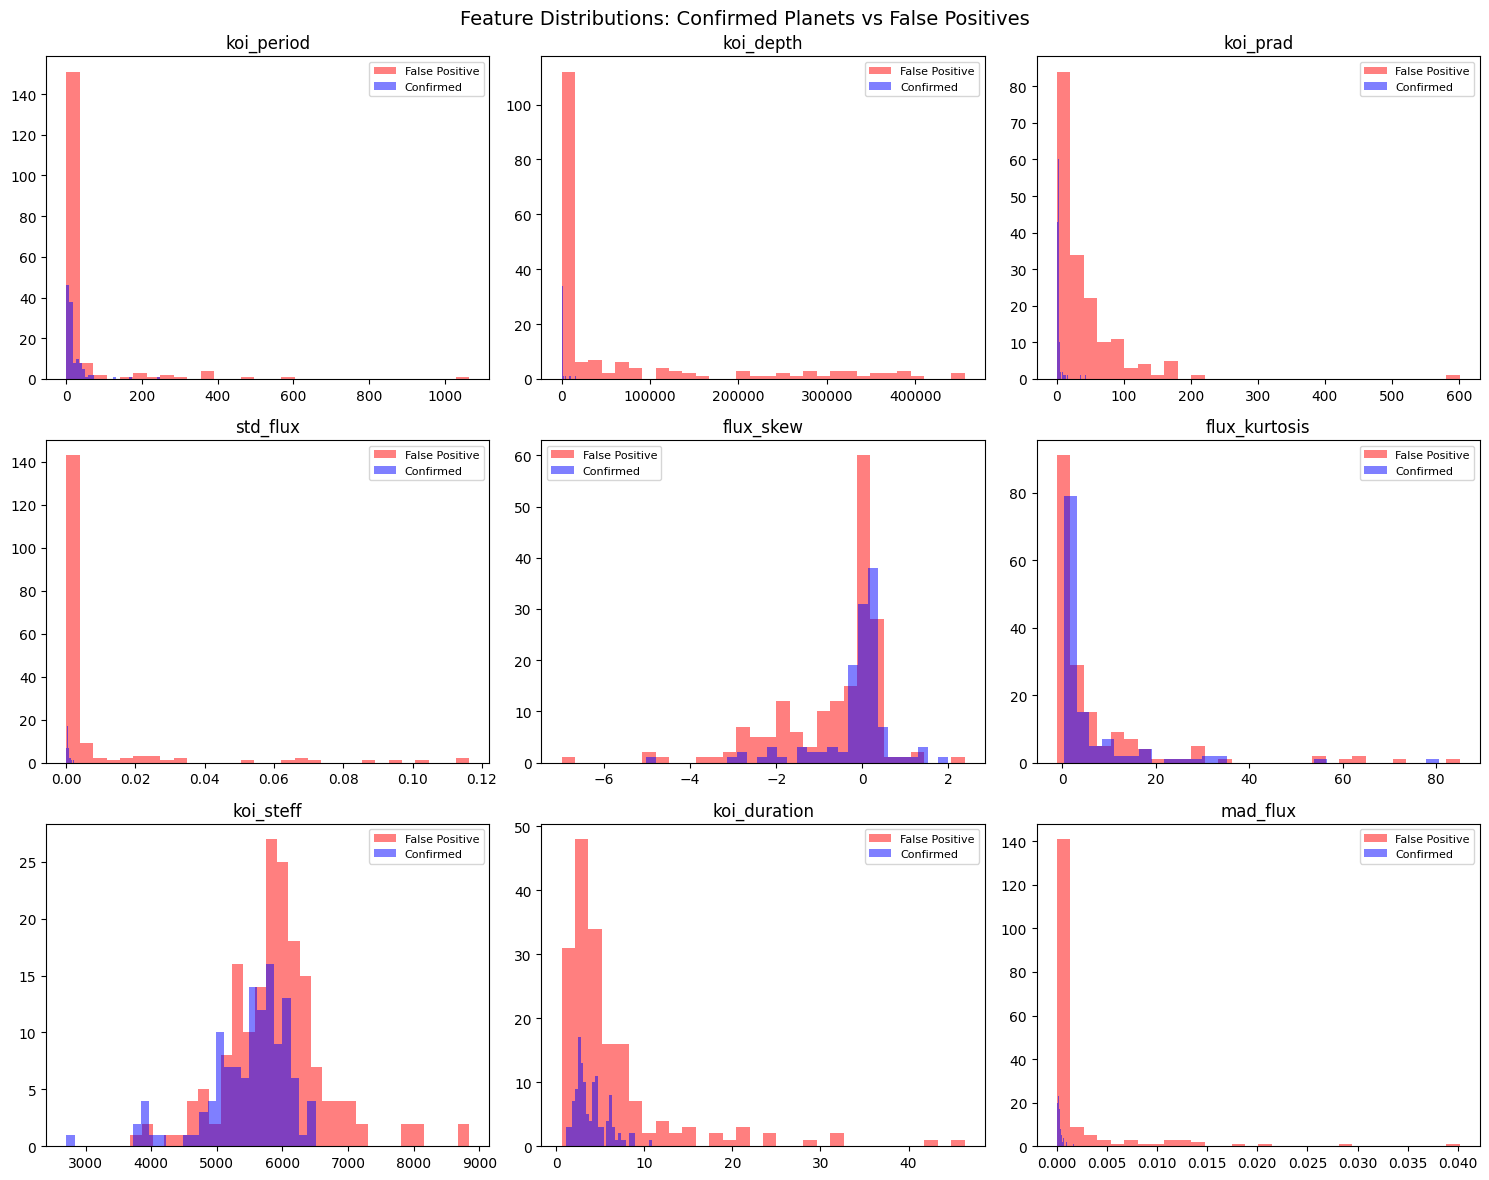

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

features_to_plot = [
    'koi_period', 'koi_depth', 'koi_prad',
    'std_flux', 'flux_skew', 'flux_kurtosis',
    'koi_steff', 'koi_duration', 'mad_flux'
]

for ax, feat in zip(axes.flat, features_to_plot):
    for label, color, name in [(0, 'red', 'False Positive'), (1, 'blue', 'Confirmed')]:
        data = df[df['label'] == label][feat].dropna()
        ax.hist(data, bins=30, alpha=0.5, color=color, label=name)
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions: Confirmed Planets vs False Positives', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/kepler_project_final/figures/feature_distributions.png', dpi=150)
plt.show()

10. Selection of Features for Classification

In [8]:
feature_cols = [
    #KOI table features
    'koi_period', 'koi_depth', 'koi_duration', 'koi_prad',
    'koi_teq', 'koi_insol', 'koi_steff', 'koi_slogg', 'koi_srad',
    #Light curve features
    'std_flux', 'flux_skew', 'flux_kurtosis', 'flux_range',
    'percentile_5', 'percentile_95', 'mad_flux'
]

df_model = df[feature_cols + ['label']].dropna()
X = df_model[feature_cols]
y = df_model['label']

print(f"Samples for modelling: {len(X)}")
print(f"  Confirmed (1): {y.sum()}")
print(f"  False pos  (0): {(y==0).sum()}")
print(f"Features: {len(feature_cols)}")

Samples for modelling: 299
  Confirmed (1): 123
  False pos  (0): 176
Features: 16


11. Starting with Classical Basline Model on Single Star with Confirmed Planet

In [ ]:
confirmed = df[df['label'] == 1].iloc[0]
star = int(confirmed['kepid'])
known_period = confirmed['koi_period']

print(f"\nTest star: KIC {star}")
print(f"Known period: {known_period:.4f} days")
print(f"Disposition: {confirmed['koi_disposition']}")


Test star: KIC 3962243
Known period: 31.8841 days
Disposition: CONFIRMED


BLS best period:  31.8812 days
Known period:     31.8841 days
Match:            1 (within 1 day)
BLS power:        0.000074


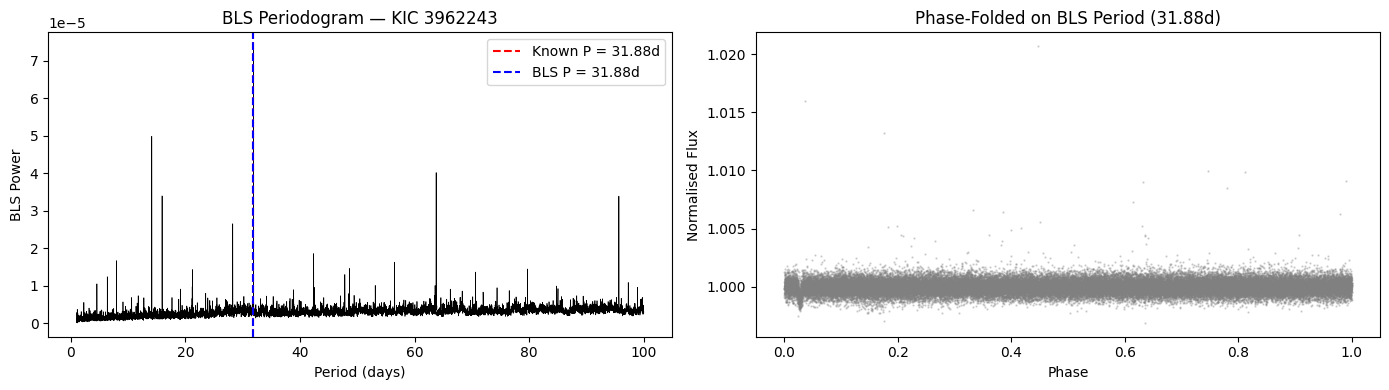

In [ ]:
# Downloading KIC 3962243 Light Curve
search = lk.search_lightcurve(f'KIC {star}', mission='Kepler', exptime=1800)
lc_collection = search.download_all()

# Manual preprocessing
time_arrays = []
flux_arrays = []

for lc_single in lc_collection:
    t = np.ascontiguousarray(lc_single.time.value, dtype=np.float64)
    f = np.ascontiguousarray(lc_single.flux.value, dtype=np.float64)
    mask = np.isfinite(t) & np.isfinite(f)
    t, f = t[mask], f[mask]
    if len(f) > 0:
        flux_arrays.append(f / np.nanmedian(f))
        time_arrays.append(t)

time_vals = np.concatenate(time_arrays)
flux_vals = np.concatenate(flux_arrays)
sort_idx = np.argsort(time_vals)
time_vals = time_vals[sort_idx]
flux_vals = flux_vals[sort_idx]

# BLS
bls = BoxLeastSquares(time_vals, flux_vals)
periods = np.linspace(1, 100, 10000)  # search 1-100 day periods
results = bls.power(periods, duration=0.2)

# Finding Best period
best_period = periods[np.argmax(results.power)]
best_power = np.max(results.power)

print(f"BLS best period:  {best_period:.4f} days")
print(f"Known period:     {known_period:.4f} days")
print(f"Match:            {abs(best_period - known_period) < 1:.0f} (within 1 day)")
print(f"BLS power:        {best_power:.6f}")

# Plot BLS periodogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(periods, results.power, 'k-', linewidth=0.5)
axes[0].axvline(known_period, color='red', linestyle='--', label=f'Known P = {known_period:.2f}d')
axes[0].axvline(best_period, color='blue', linestyle='--', label=f'BLS P = {best_period:.2f}d')
axes[0].set_xlabel('Period (days)')
axes[0].set_ylabel('BLS Power')
axes[0].set_title(f'BLS Periodogram — KIC {star}')
axes[0].legend()

# Phase-fold on BLS period
phase = (time_vals % best_period) / best_period
sort_phase = np.argsort(phase)
axes[1].scatter(phase, flux_vals, s=0.5, alpha=0.3, color='grey')
axes[1].set_xlabel('Phase')
axes[1].set_ylabel('Normalised Flux')
axes[1].set_title(f'Phase-Folded on BLS Period ({best_period:.2f}d)')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/kepler_project/figures/bls_demo.png', dpi=150)
plt.show()

In [ ]:
# Unique star IDs from merged data set
unique_stars = df['kepid'].unique()
print(f"Total stars: {len(unique_stars)}")

bls_features = []

for i, star in enumerate(tqdm(unique_stars, desc="Processing stars")):
    try:
      search = lk.search_lightcurve(f'KIC {int(star)}', mission='Kepler', exptime=1800)
      if len(search) == 0:
          continue

      lc_collection = search.download_all()

      # preprocessing
      time_arrays = []
      flux_arrays = []

      for lc_single in lc_collection:
          t = np.ascontiguousarray(lc_single.time.value, dtype=np.float64)
          f = np.ascontiguousarray(lc_single.flux.value, dtype=np.float64)
          mask = np.isfinite(t) & np.isfinite(f)
          t, f = t[mask], f[mask]
          if len(f) > 0:
              flux_arrays.append(f / np.nanmedian(f))
              time_arrays.append(t)

      time_vals = np.concatenate(time_arrays)
      flux_vals = np.concatenate(flux_arrays)
      sort_idx = np.argsort(time_vals)
      time_vals = time_vals[sort_idx]
      flux_vals = flux_vals[sort_idx]

      #  BLS Execution
      bls = BoxLeastSquares(time_vals, flux_vals)
      periods = np.linspace(0.5, 100, 5000)
      results = bls.power(periods, duration=0.2)

      best_idx = np.argmax(results.power)
      best_period = periods[best_idx]
      best_power = float(results.power[best_idx])

      # get known period for comparison
      known_period = df[df['kepid'] == star]['koi_period'].values[0]
      period_match = abs(best_period - known_period) / known_period

      bls_features.append({
          'kepid': int(star),
          'bls_best_period': best_period,
          'bls_best_power': best_power,
          'bls_period_match': period_match,
          'period_recovered': 1 if period_match < 0.05 else 0
      })

      if (i + 1) % 50 == 0:
          print(f"  Processed {i + 1} stars")

    except Exception as e:
        continue

df_bls = pd.DataFrame(bls_features)
df_bls.to_csv('/content/drive/MyDrive/kepler_project_final/data/bls_features.csv', index=False)

print(f"\nBLS Complete: {len(df_bls)} stars processed")
print(f"Periods recovered (within 5%): {df_bls['period_recovered'].sum()} / {len(df_bls)}")
print(f"Recovery rate: {df_bls['period_recovered'].mean()*100:.1f}%")

Total stars: 293


Processing stars:  17%|█▋        | 50/293 [04:09<14:37,  3.61s/it]

  Processed 50 stars


Processing stars:  34%|███▍      | 100/293 [08:36<14:08,  4.40s/it]

  Processed 100 stars


...

  Processed 200 stars


Processing stars:  85%|████████▌ | 250/293 [21:30<03:57,  5.52s/it]

  Processed 250 stars


Processing stars: 100%|██████████| 293/293 [25:15<00:00,  5.17s/it]


BLS Complete: 293 stars processed
Periods recovered (within 5%): 58 / 293
Recovery rate: 19.8%


Confirmed           : 19/123 periods recovered (15.4%)
False Positive      : 39/176 periods recovered (22.2%)

Overall: 58/299 (19.4%)


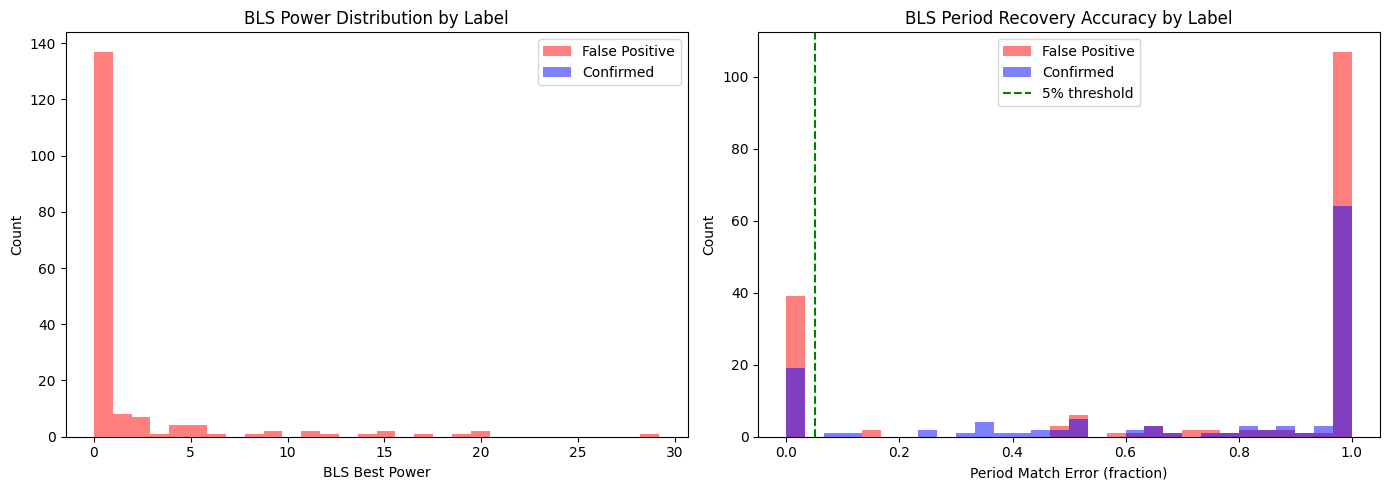

In [13]:
# Load BLS features and merge
df_bls = pd.read_csv('/content/drive/MyDrive/kepler_project_final/data/bls_features.csv')
df_with_bls = df.merge(df_bls, on='kepid', how='inner')
df_combined.to_csv('/content/drive/MyDrive/kepler_project_final/data/dataset_with_bls.csv', index=False)

# Recovery rate by label
for label, name in [(1, 'Confirmed'), (0, 'False Positive')]:
    subset = df_with_bls[df_with_bls['label'] == label]
    rate = subset['period_recovered'].mean() * 100
    total = len(subset)
    recovered = subset['period_recovered'].sum()
    print(f"{name:20s}: {recovered:.0f}/{total} periods recovered ({rate:.1f}%)")

print(f"\nOverall: {df_with_bls['period_recovered'].sum():.0f}/{len(df_with_bls)} ({df_with_bls['period_recovered'].mean()*100:.1f}%)")

# BLS power distribution by label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for label, color, name in [(0, 'red', 'False Positive'), (1, 'blue', 'Confirmed')]:
    subset = df_with_bls[df_with_bls['label'] == label]
    axes[0].hist(subset['bls_best_power'], bins=30, alpha=0.5, color=color, label=name)

axes[0].set_xlabel('BLS Best Power')
axes[0].set_ylabel('Count')
axes[0].set_title('BLS Power Distribution by Label')
axes[0].legend()

# Period match accuracy by label
for label, color, name in [(0, 'red', 'False Positive'), (1, 'blue', 'Confirmed')]:
    subset = df_with_bls[df_with_bls['label'] == label]
    match = subset['bls_period_match'].clip(upper=1)  # cap at 100% error
    axes[1].hist(match, bins=30, alpha=0.5, color=color, label=name)

axes[1].set_xlabel('Period Match Error (fraction)')
axes[1].set_ylabel('Count')
axes[1].set_title('BLS Period Recovery Accuracy by Label')
axes[1].axvline(0.05, color='green', linestyle='--', label='5% threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/kepler_project/figures/bls_analysis.png', dpi=150)
plt.show()

In [14]:
# Merge BLS features into main dataset
df_combined = df.merge(df_bls, on='kepid', how='inner')

# Model WITHOUT BLS features
feature_cols_base = [
    'koi_period', 'koi_depth', 'koi_duration', 'koi_prad',
    'koi_teq', 'koi_insol', 'koi_steff', 'koi_slogg', 'koi_srad',
    'std_flux', 'flux_skew', 'flux_kurtosis', 'flux_range',
    'percentile_5', 'percentile_95', 'mad_flux'
]

# Model WITH BLS features
feature_cols_bls = feature_cols_base + ['bls_best_power', 'bls_period_match', 'period_recovered']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model WITH BLS features
feature_cols_bls = feature_cols_base + ['bls_best_power', 'bls_period_match', 'period_recovered']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Test both feature sets
for name, cols in [('Without BLS', feature_cols_base), ('With BLS', feature_cols_bls)]:
    df_temp = df_combined[cols + ['label']].dropna()
    X_temp = df_temp[cols]
    y_temp = df_temp['label']

    rf_acc = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=42),
                             X_temp, y_temp, cv=cv, scoring='accuracy')
    rf_auc = cross_val_score(RandomForestClassifier(n_estimators=200, random_state=42),
                             X_temp, y_temp, cv=cv, scoring='roc_auc')

    xgb_acc = cross_val_score(XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                             random_state=42, eval_metric='logloss'),
                               X_temp, y_temp, cv=cv, scoring='accuracy')
    xgb_auc = cross_val_score(XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                                             random_state=42, eval_metric='logloss'),
                               X_temp, y_temp, cv=cv, scoring='roc_auc')

    print(f"\n--- {name} ({len(cols)} features) ---")
    print(f"Random Forest:  Acc = {rf_acc.mean():.3f} ± {rf_acc.std():.3f}  AUC = {rf_auc.mean():.3f} ± {rf_auc.std():.3f}")
    print(f"XGBoost:        Acc = {xgb_acc.mean():.3f} ± {xgb_acc.std():.3f}  AUC = {xgb_auc.mean():.3f} ± {xgb_auc.std():.3f}")


--- Without BLS (16 features) ---
Random Forest:  Acc = 0.836 ± 0.032  AUC = 0.913 ± 0.045
XGBoost:        Acc = 0.823 ± 0.034  AUC = 0.907 ± 0.037

--- With BLS (19 features) ---
Random Forest:  Acc = 0.846 ± 0.032  AUC = 0.916 ± 0.044
XGBoost:        Acc = 0.823 ± 0.034  AUC = 0.907 ± 0.032
